# Problema de valores propios en 1D con elementos finitos

Queremos resolver el siguiente problema de valores propios

$$\frac{d^2 u}{dx^2} = -k^2 u(x)\, ,$$

con $u(0) = u(1)  = 0$.

Vamos a usar una solución aproximada de la forma

$$u(x) = \sum_{n=0}^{N} u_n \phi_n(x)\, ,$$

Si usamos el método de Galerkin, la ecuación diferencial es equivalente
al siguiente problema

$$\int_{0}^{1} \frac{d u}{d x} \frac{d \phi_n}{d x} dx
= \lambda^2 \int_{0}^{1}  u(x)\phi_n dx\, \quad \forall \phi_n\, .$$

Si remplazamos $u(x)$ en este sistema obtenemos

$$\sum_{j=0}^N \left[\int_{0}^{1} \frac{d \phi_i}{d x} \frac{d \phi_j}{d x} dx\right] u_j
= \lambda^2 \sum_{j=0}^N \left[\int_{0}^{1} \phi_i \phi_j dx\right] u_j\, \quad \forall \phi_j\, .$$

Esto lleva al siguiente problema de valores propios generalizado

$$[K]\{\mathbf{u}\} = \lambda^2[M]\{\mathbf{u}\}$$

donde las matrices de rigidez locales están dadas por

$$K_\text{local} =  \frac{1}{|J|}\begin{bmatrix} 2 & -2\\ -2 &2\end{bmatrix}$$

y

$$M_\text{local} =  \frac{|J|}{3}\begin{bmatrix} 2 & 1\\ 1 &2\end{bmatrix}$$

donde $|J|$ es el determinante jacobiano.

In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

In [4]:
# Configuracion graficos
gris = '#757575'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.color"] = gris
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.color"] = gris
plt.rcParams["ytick.color"] = gris
plt.rcParams["axes.labelcolor"] = gris
plt.rcParams["axes.edgecolor"] = gris
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

In [5]:
def FEM1D(coords):
    N = len(coords)
    stiff_loc = np.array([[2.0, -2.0],
                          [-2.0, 2.0]])
    mass_loc = np.array([[2/3, 1/3],
                         [1/3, 2/3]])
    eles = [np.array([cont, cont + 1]) for cont in range(0, N - 1)]
    stiff = np.zeros((N, N))
    mass = np.zeros((N, N))
    for ele in eles:  ## Ensamblaje
        jaco = coords[ele[1]] - coords[ele[0]]
        for cont1, row in enumerate(ele):
            for cont2, col in enumerate(ele):
                stiff[row, col] = stiff[row, col] +  stiff_loc[cont1, cont2]/jaco
                mass[row, col] = mass[row, col] +  jaco*mass_loc[cont1, cont2]
    return stiff, mass

Para este caso, la solución analítica del problema es

$$u_n = \sin(n \pi x)\, ,\quad \lambda_n = n \pi\, .$$

In [6]:
N = 200
nvals = 50
x = np.linspace(0, 1, N)

Podemo usar ``FEM1D`` para obtener las matrices de rigidez y masa.

In [7]:
stiff, mass = FEM1D(x)

Y estas matrices podemos usarlas para resolver el problema de valores
propios generalizado con ``eigh``.

En este caso no tomamos la matriz completa sino que dejamos por
fuera las filas/columnas correspondientes al primer y último
grado de libertad ya que tenemos condiciones de Dirichlet homogéneas.

In [8]:
vals, vecs = eigh(stiff[1:-1, 1:-1],
                  mass[1:-1, 1:-1],
                  subset_by_index=(0, nvals - 1))

Y podemos comparar esto con la solución analítica

In [9]:
vals_ex = np.round([k**2 * np.pi**2 for k in range(1, nvals + 1)], 4)

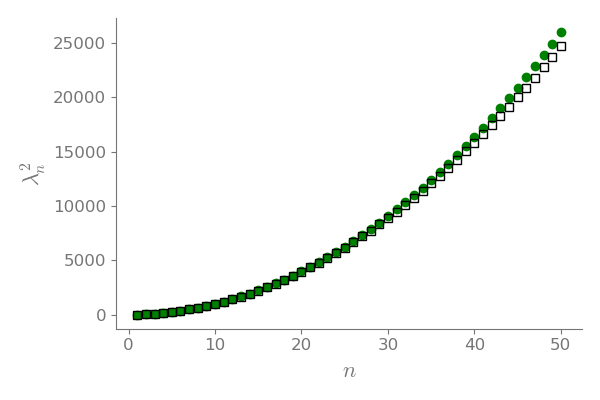

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, nvals + 1), vals, "o", color="green")
plt.plot(range(1, nvals + 1), vals_ex, "s", mec="black",
         mfc="#FFFFFF00")
plt.xlabel(r"$n$", fontsize=16)
plt.ylabel(r"$\lambda_n^2$", fontsize=16)
plt.tight_layout()

Podemos comparar la solución numérica con la solución analítica.

Para ello completamos los vectores propios con los ceros en los extremos
primero.

In [11]:
vecs_comp = np.zeros((N, nvals))
vecs_comp[1:-1, :] = vecs

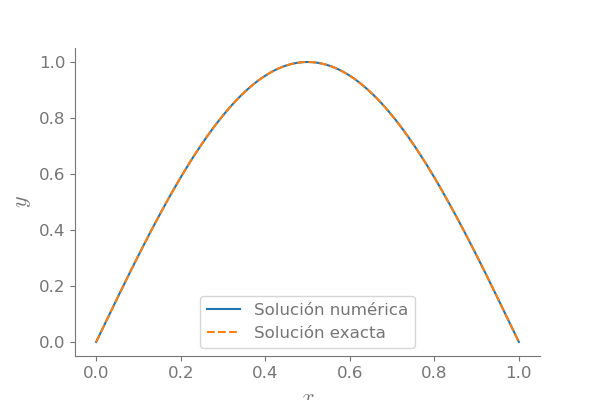

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(x, vecs_comp[:, 0])
plt.plot(x, np.sin(np.pi*x), linestyle="dashed")
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel(r"$y$", fontsize=16)
plt.legend(["Solución numérica", "Solución exacta"])
plt.show()

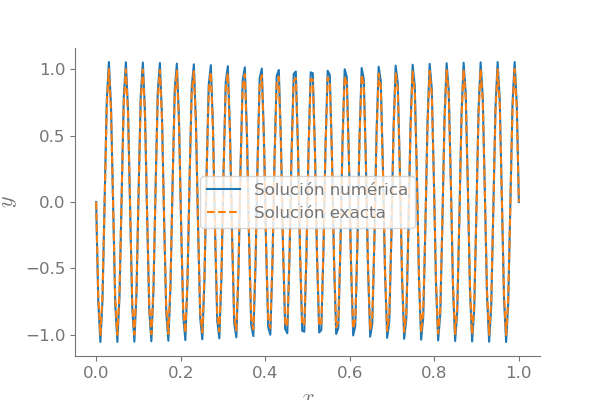

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(x, vecs_comp[:, 49])
plt.plot(x, -np.sin(50*np.pi*x), linestyle="dashed")
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel(r"$y$", fontsize=16)
plt.legend(["Solución numérica", "Solución exacta"])
plt.show()